In [1]:
## Load in the confocal data
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np



## Results dataframes
confocal_df = pd.read_csv("../output/confocal_results_df_batch.csv")
idealised_df = pd.read_csv("../output/idealised_results_df.csv")

## Set the colours for the three mesh types
colours = {
    'empirical': 'magenta',
    'anisotropic': "#8A0CA1",
    'idealised_circular': 'orange',
    'idealised_oval': 'green',
    'midsection' : 'magenta',
    'tip' : "yellow"
}

# Set the default font size for all plots
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'Open Sans']
plt.rcParams['font.size'] = 14
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

## Set the name for each mesh
mesh_dcr = "Sample"

## Choose meshes to include based on their pore length : length
stomata_length = [43, 40,40.5, 48.2, 45.2, 40.3, 37, 39.6, 37.5, 36, 40, 42.1, 41.6, 40.6, 40.5, 45.5, 41]
pore_length = [13.1, 12.6, 13.6, 13.6, 16.6, 14.0, 12.2, 14.7, 10.8, 6.8, 13.0, 8.7, 11.2, 6.7, 11.9, 14.3, 11.3]
mesh_ids =["1_2","1_3","1_4","1_5","1_6","1_8","2_1", "2_3", "2_6a", "2_6b", "2_7","3_1","3_2", "3_3", "3_4","3_6", "3_7"]
print(len(mesh_ids))

pore_proportion = [p / s for p, s in zip(pore_length, stomata_length)]

threshold = 0.25
prop_mask = [p > threshold for p in pore_proportion]
selected_meshes = [m for m, keep in zip(mesh_ids, prop_mask) if keep]
print("Selected meshes:", selected_meshes)


17
Selected meshes: ['1_2', '1_3', '1_4', '1_5', '1_6', '1_8', '2_1', '2_3', '2_6a', '2_7', '3_2', '3_4', '3_6', '3_7']


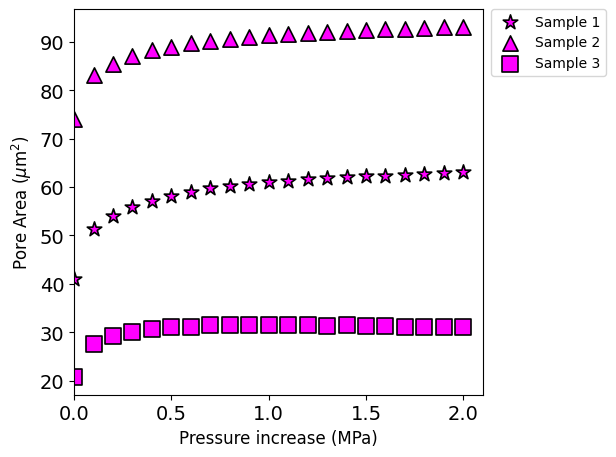

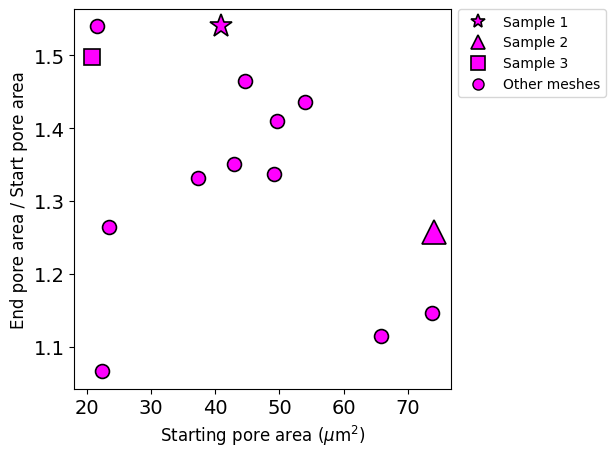

In [2]:
## Figure 1
import importlib
import plot_fig1 as pf1
importlib.reload(pf1)

pf1.run_plot_fig1(confocal_df=confocal_df, colours=colours, mesh_dcr=mesh_dcr)

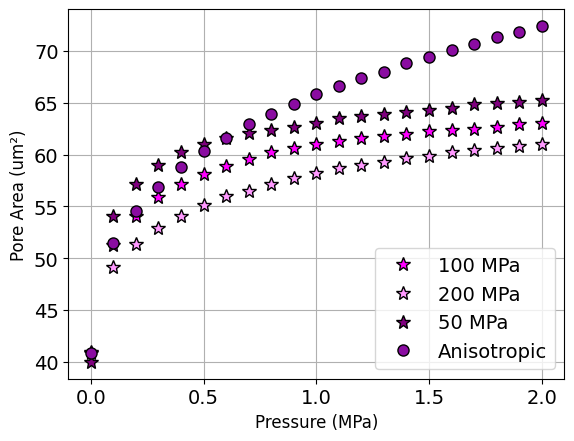

In [3]:
## Fig1e. Changes to the stiffness of the cell wall (Youngs modulus) do not qualitatively impact the results. Introducing circumferential stiffening (anisotropy - red circles) increases the resulting pore area
## Look at the effect of anisotropy (e1e3100 e2200)

import matplotlib.pyplot as plt
import colorsys
import matplotlib.colors as mcolors

def adjust_lightness(rgb, factor):
        h, l, s = colorsys.rgb_to_hls(*rgb)
        l = min(1.0, max(0.0, l * factor))
        return colorsys.hls_to_rgb(h, l, s)

pressure = [0,0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0]
pore_area_1_2 = [40.92, 51.25, 54.1, 55.9, 57.2, 58.1, 58.9, 59.6, 60.2, 60.6, 61, 61.3, 61.6, 61.8, 62, 62.3, 62.4, 62.5, 62.7, 62.9, 63]
pore_area_1_2_double = [40.9, 49.2, 51.4, 52.9, 54.1, 55.1, 56.0, 56.5, 57.2, 57.7, 58.2, 58.7, 59.0, 59.3, 59.7, 59.9, 60.2, 60.4, 60.6, 60.8, 61.0]
pore_area_1_2_half = [40.0, 54.1, 57.2, 59.0, 60.2, 61.0, 61.6, 62.1, 62.4, 62.7, 63.0, 63.5, 63.7, 63.9, 64.1, 64.3, 64.5, 64.9, 65.0, 65.1, 65.3]

pore_area_1_2_aniso = [40.9, 51.5, 54.6, 56.9, 58.8, 60.3, 61.6, 62.9, 63.9, 64.9, 65.8, 66.6, 67.4, 68.0, 68.8, 69.4, 70.1, 70.7, 71.3, 71.8, 72.4]

base_colour = mcolors.to_rgb(colours['empirical'])

plt.plot(pressure, pore_area_1_2, color = base_colour, marker = '*', linestyle = 'None', markeredgecolor = "k", markersize = 10, label='100 MPa')
plt.plot(pressure, pore_area_1_2_double, color = adjust_lightness(base_colour, 1.6), marker = '*', linestyle = 'None',  markeredgecolor = "k", markersize = 10, label='200 MPa')
plt.plot(pressure, pore_area_1_2_half, color = adjust_lightness(base_colour, 0.5), marker = '*', linestyle = 'None', markeredgecolor = "k", markersize = 10, label='50 MPa')

plt.plot(pressure, pore_area_1_2_aniso, colours['anisotropic'], marker = "o", linestyle = 'None', markeredgecolor = "k", markersize = 8,label='Anisotropic')
plt.xlabel('Pressure (MPa)')
plt.ylabel('Pore Area (um²)')
#plt.title('Pressure vs Pore Area (Isotropic vs Anisotropic)')
plt.grid(True)
plt.legend()
plt.savefig("../Figures/Fig1/pressure_vs_pore_area_aniso.png", dpi=300)
plt.show()

Paired t-test: p = 1.6e-07
Wilcoxon signed-rank: p = 2.46e-07


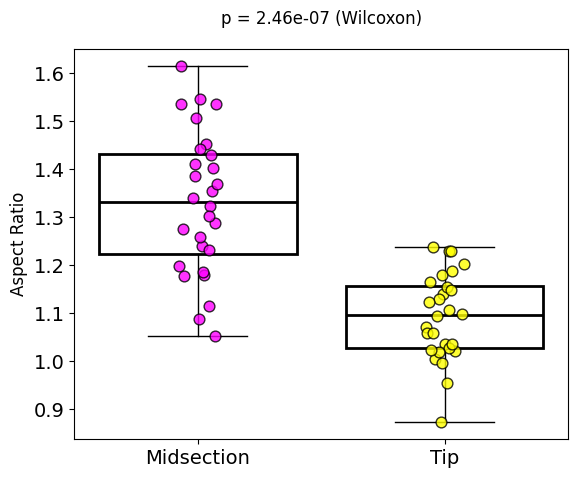

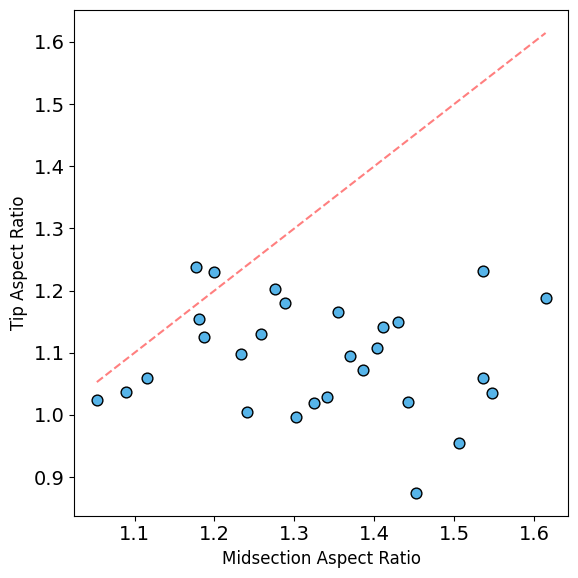

In [4]:
## Plot Figure 2
import importlib
import plot_fig2 as pf2
importlib.reload(pf2)
pf2.run_plot_fig2(confocal_df=confocal_df, colours=colours)



In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
## Figure 3: 
## a) Cross-sectional aspect ratio drives geometry-derived stomatal opening

## Load in the idealised results
df_idealised = pd.read_csv("../output/idealised_results_df.csv")
df_idealised_pore_area = pd.read_csv("../output/idealised_results_pore_area_df.csv")
df_idealised_cross_section = pd.read_csv("../output/idealised_results_cross_sections_df.csv")

## Combine our dataframes into a single dataframe
df_combined = df_idealised_pore_area.merge(df_idealised_cross_section, on=["Mesh ID", "Pressure", "Cross-section type"])

df_combined.head()

,Mesh ID,Cross-section type,Pressure,Pore Area,Cross section,Aspect Ratio
0,2_6a,circular,0.8,19.8944,[[-1.89380e+00 3.70945e-06]\n [-1.89773e+00 ...,0.954685
1,1_2,circular,0.0,40.9739,[[-2.81262 0. ]\n [-2.81671 0.260701]...,1.000519
2,3_4,circular,1.6,18.0763,[[-1.33900e+00 -6.69476e-04]\n [-1.34326e+00 ...,0.953271
3,2_1,oval,1.7,80.5220,[[-4.81271e+00 1.47737e-04]\n [-4.81541e+00 ...,1.041856
4,1_8,circular,1.1,61.9714,[[-3.56219e+00 -2.04021e-07]\n [-3.56594e+00 ...,0.958226


Skipping mesh 3_7 due to missing start or end data in idealised circular.


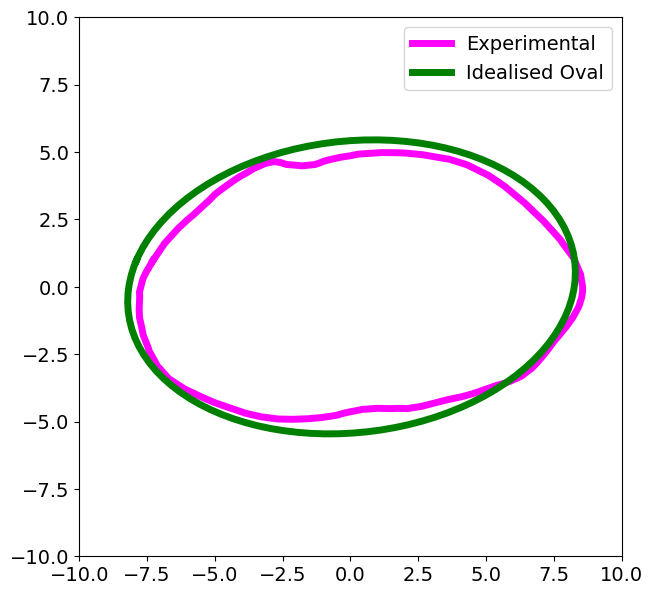

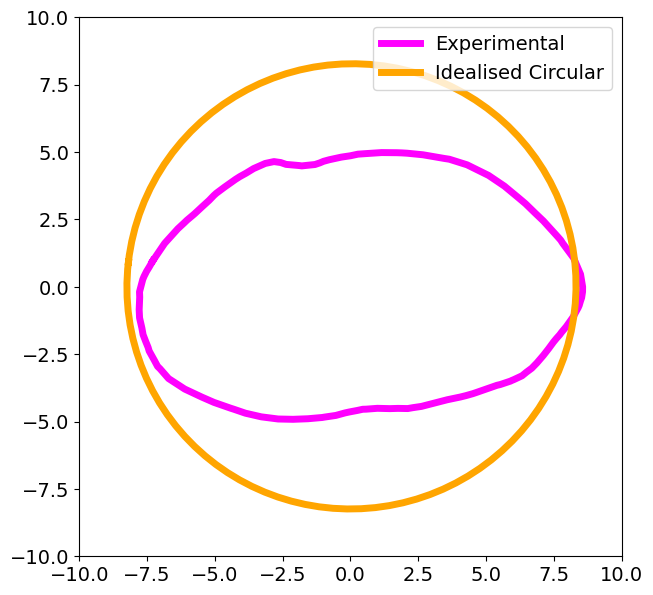

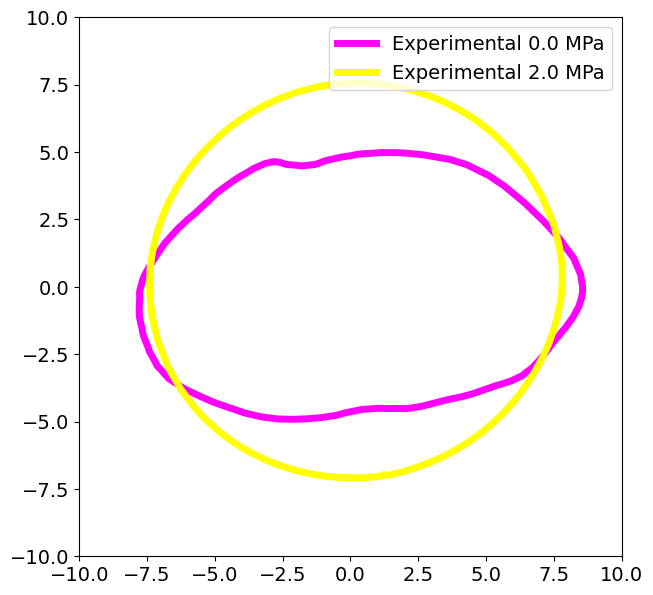

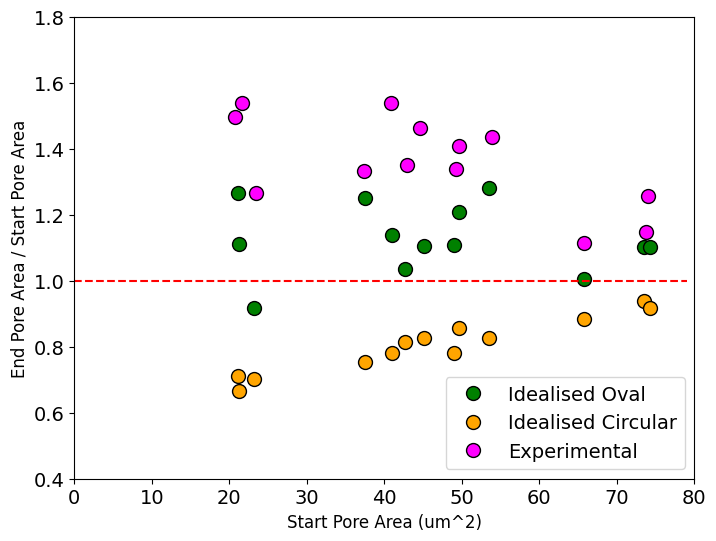

Skipping mesh 3_7 due to missing start or end data in idealised circular.
Oval: Linear regression: slope = 0.461 ± 0.164, intercept = 0.502, Pearson r = 0.646, p-value = 0.0171
Empirical: Linear regression: slope = 0.561 ± 0.248, intercept = 0.604, Pearson r = 0.564, p-value = 0.0449


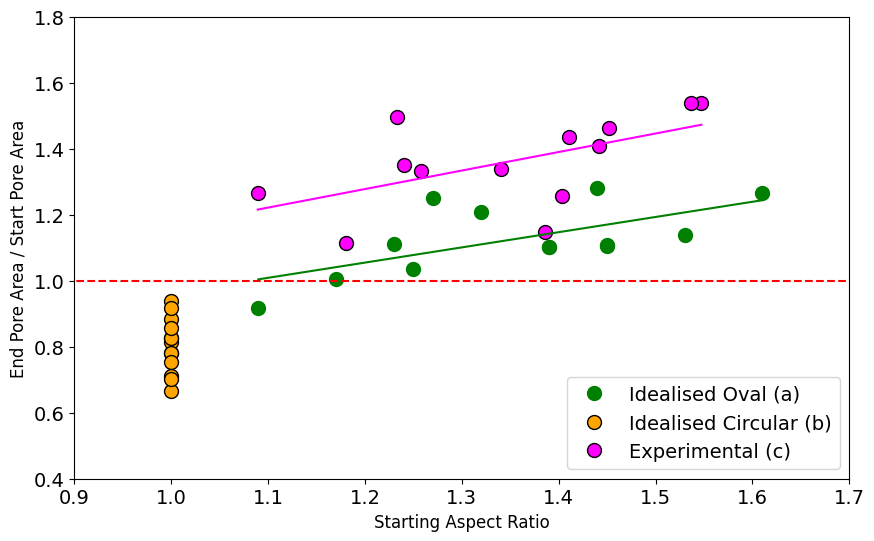

Skipping mesh 3_7 due to missing start or end data in idealised circular.


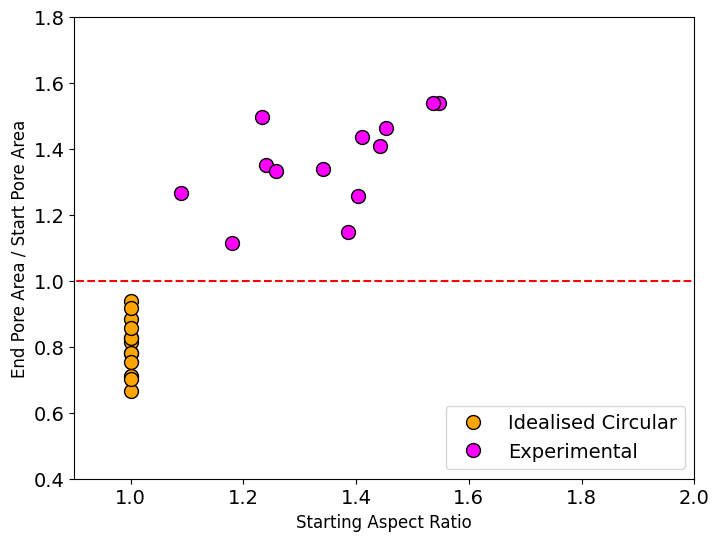

In [6]:
## Figure 3

import importlib
import plot_fig3 as pf3
importlib.reload(pf3)

oval_path = "../Meshes/Idealised/idealised_final_1_2_oval.obj"
circular_path = "../Meshes/Idealised/idealised_final_1_2_circular.obj"
pf3.run_plot_fig3(idealised_df=idealised_df, colours=colours, oval_path=oval_path, circular_path=circular_path, confocal_df=confocal_df, df_combined = df_combined, selected_meshes=selected_meshes)

## Let's also plot a version that doesn't include the oval data, for Figure 2.
pf3.AR_area_change_no_oval(selected_meshes, df_combined=df_combined, confocal_df = confocal_df, colours = colours)

In [7]:
## Figure 4: Anisotropy
## Plot guard cell length - does this change with inflation?
## Anisotropy - how does this affect opening dynamics?
## Can we show that initial differences in opening are due to geometry, whereas later differences are due to anisotropy?
## Which morphospace do plants need to live in?
import sys
from pathlib import Path
import pandas as pd

src_path = str(Path.cwd().parent / "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

import cross_section_helpers as csh
import importlib
importlib.reload(csh)
from mesh_functions import process_mesh_pressure
import numpy as np
from concurrent.futures import ProcessPoolExecutor

# Use linspace or round arange to avoid floating-point issues
pressures = np.round(np.arange(0, 2.1, 0.1), 1)

midsection_areas = pd.read_csv("../output/midsection_areas.csv")
area_map = {row['mesh_file']: (row['midsection_area1'], row['midsection_area2']) for _, row in midsection_areas.iterrows()}

# Validate that all selected meshes have area data
for mesh in selected_meshes:
    mesh_file = f"Ac_DA_{mesh}_0.0.obj"
    if mesh_file not in area_map:
        print(f"WARNING: No midsection area data found for {mesh_file}")

## Set up whether isotropic or anisotropic
stiffening = "isotropic"

# Update tasks to include midsection areas
tasks = []
for mesh in selected_meshes:
    mesh_file = f"Ac_DA_{mesh}_0.0.obj"
    area1, area2 = area_map.get(mesh_file, (None, None))
    if area1 is None or area2 is None:
        print(f"WARNING: Missing area data for {mesh}, using None")
    for p in pressures:
        tasks.append((mesh, p, area1, area2, stiffening))

results_matrix_iso = np.zeros((len(selected_meshes), len(pressures)))

with ProcessPoolExecutor() as executor:
    results_flat = list(executor.map(process_mesh_pressure, tasks))

# Reshape results to (meshes, pressures)
for i, mesh in enumerate(selected_meshes):
    results_matrix_iso[i, :] = results_flat[i*len(pressures):(i+1)*len(pressures)]

# If you want the same structure as before:
results_iso = [list(row) for row in results_matrix_iso]

## Repeat for anisotropic stiffening
stiffening = "anisotropic"

# Update tasks to include midsection areas
tasks = []
for mesh in selected_meshes:
    mesh_file = f"Ac_DA_{mesh}_0.0.obj"
    area1, area2 = area_map.get(mesh_file, (None, None))
    for p in pressures:
        tasks.append((mesh, p, area1, area2, stiffening))

results_matrix_aniso = np.zeros((len(selected_meshes), len(pressures)))

with ProcessPoolExecutor() as executor:
    results_flat = list(executor.map(process_mesh_pressure, tasks))

# Reshape results to (meshes, pressures)
for i, mesh in enumerate(selected_meshes):
    results_matrix_aniso[i, :] = results_flat[i*len(pressures):(i+1)*len(pressures)]

# If you want the same structure as before:
results_aniso = [list(row) for row in results_matrix_aniso]

Checking results_matrix_iso for zeros or NaNs:
  Zeros: 0
  NaNs: 0
  Shape: (14, 21)
  Min value: 66.16561345471483
  Max value: 83.55099036729317

Checking results_matrix_aniso for zeros or NaNs:
  Zeros: 0
  NaNs: 0
  Shape: (14, 21)
  Min value: 66.06495362550432
  Max value: 85.28646479763236


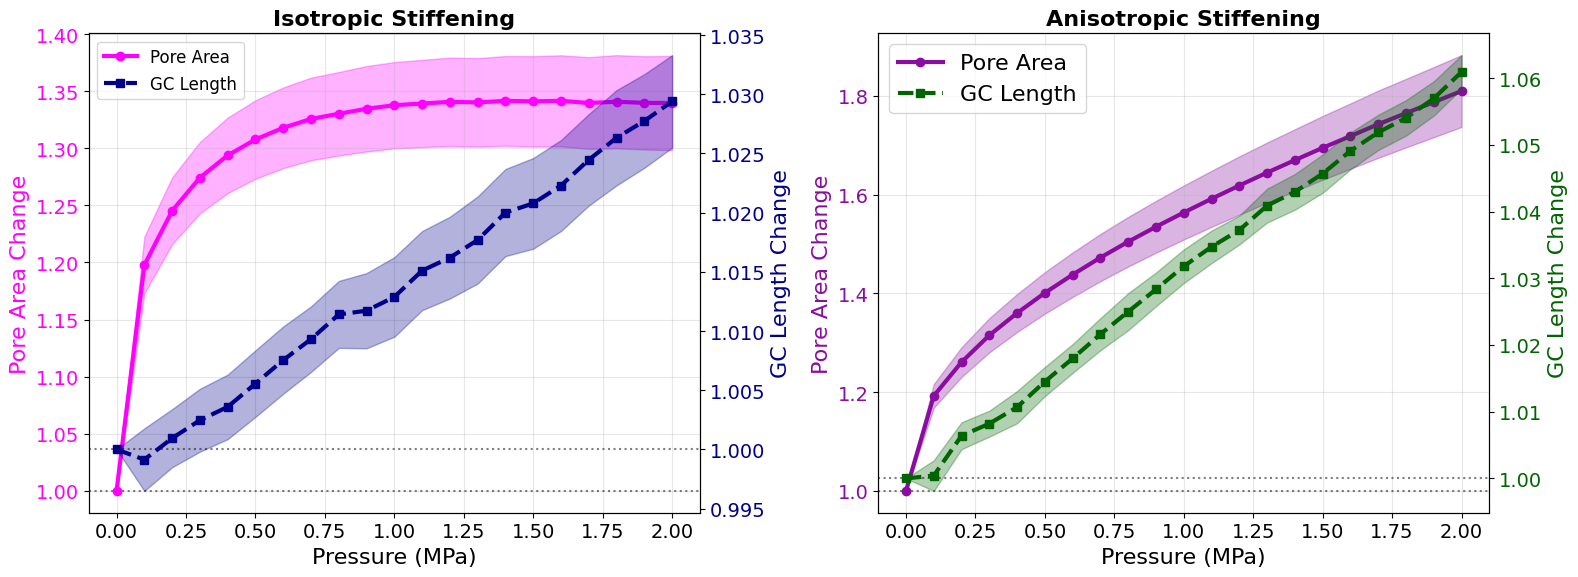

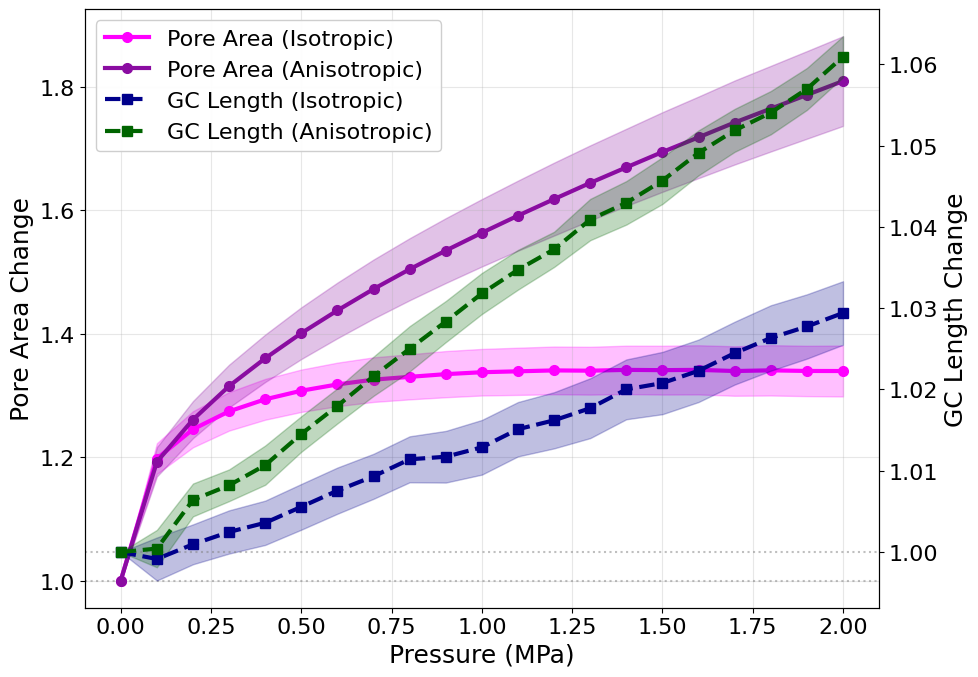


=== Summary Statistics ===
Final GC Length Change (Isotropic): 1.029 ± 0.004
Final GC Length Change (Anisotropic): 1.061 ± 0.003
Final Pore Area Change (Isotropic): 1.340 ± 0.041
Final Pore Area Change (Anisotropic): 1.810 ± 0.073

=== Ratio of Changes ===
Pore Area / GC Length (Isotropic): 11.55x
Pore Area / GC Length (Anisotropic): 13.29x


In [8]:
## Plot Figure 4

import plot_fig4 as pf4
importlib.reload(pf4)

confocal_df_aniso = pd.read_csv("../output/confocal_aniso_results_df_batch.csv")
## Calculate normalized pore area change for all meshes
confocal_df["Pore Area Change"] = np.nan
confocal_df_aniso["Pore Area Change"] = np.nan

pf4.run_plot_fig4(results_matrix_iso, results_matrix_aniso, selected_meshes, confocal_df, confocal_df_aniso, pressures, colours)


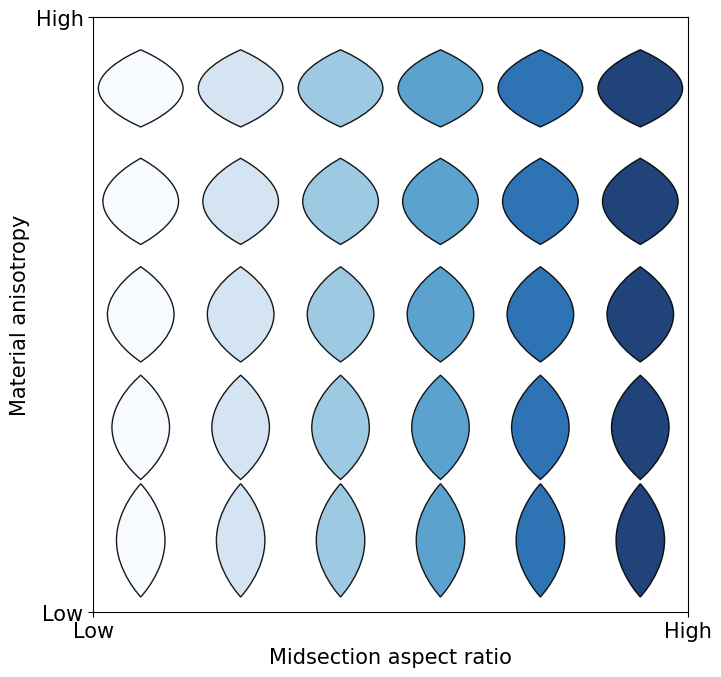

In [9]:
## Figure 5: Conceptual figure of morphospace for Discussion
from plot_fig5 import run_plot_fig5
run_plot_fig5()


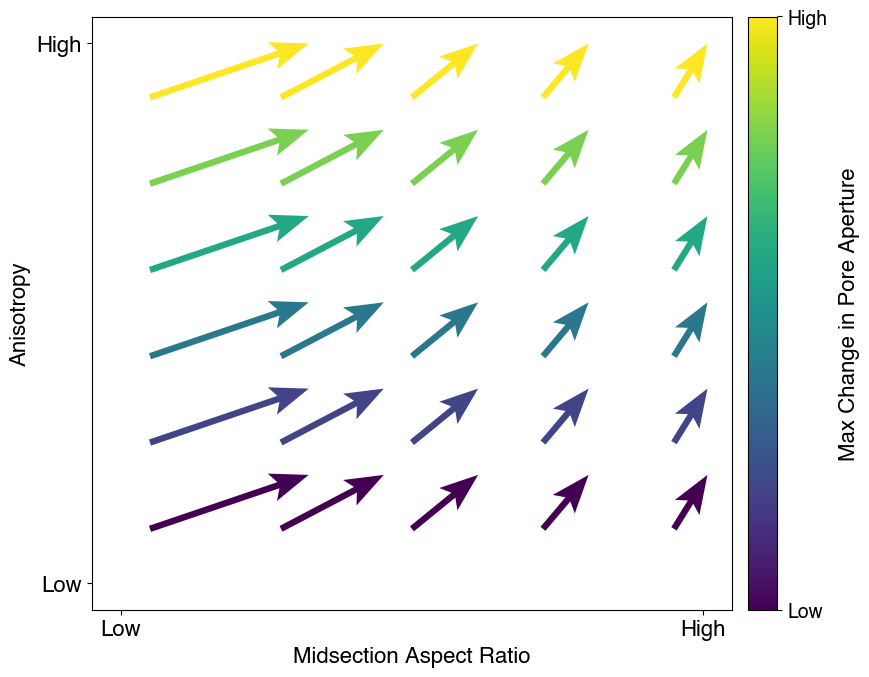

Arrow interpretation:
- All arrows reach the same vertical distance
- Steeper, shorter arrows = higher aspect ratio = faster opening
- Longer, shallower arrows = lower aspect ratio = slower opening
- Color = maximum pore aperture (anisotropy effect)

Speed range: 0.37 to 1.74 (4.7x difference)
Slope range: 0.37 to 1.74 (4.7x difference)
Arrow length range: 0.115 to 0.290

Slope by column (left to right):
  Column 1: slope = 0.37
  Column 2: slope = 0.57
  Column 3: slope = 0.88
  Column 4: slope = 1.28
  Column 5: slope = 1.74


In [ ]:
## Alternative version of Figure 5 with improved arrow spacing and slope differences

import numpy as np
import matplotlib.pyplot as plt

# Reduced grid for better spacing and clearer slope differences
nx, ny = 5, 6  # fewer columns for better spacing
X, Y = np.meshgrid(np.linspace(0.05, 0.95, nx), np.linspace(0.1, 0.9, ny))

# Conceptual relationship:
# - Aspect ratio (X) determines RATE/SPEED of opening (slope)
# - Anisotropy (Y) determines MAX APERTURE (color)

# Define a fixed vertical distance all arrows should reach
target_height = 0.10

# Speed/rate with moderate, more linear progression
# More linear change = easier to see each step
speed = 0.35 + 1.5*X**1.5  # More linear (exponent 1.5), moderate range

# For arrows to reach the same height with different slopes:
V_final = np.ones_like(X) * target_height  # fixed vertical component
U_final = V_final / speed  # horizontal component inversely proportional to speed

# Color represents max aperture increasing with anisotropy (Y)
aperture = 0.2 + 0.8*Y

fig, ax = plt.subplots(figsize=(9, 7))
q = ax.quiver(
    X, Y, U_final, V_final, aperture, 
    scale=1.0,
    cmap='viridis', 
    width=0.010,
    headwidth=4.5,
    headlength=6,
    headaxislength=5,
    angles='xy',
    scale_units='xy'
)

ax.set_xlabel('Midsection Aspect Ratio', fontsize=16)
ax.set_ylabel('Anisotropy', fontsize=16)

# Clean axes
ax.set_xticks([0, 1])
ax.set_xticklabels(['Low', 'High'], fontsize=16)
ax.set_yticks([0, 1])
ax.set_yticklabels(['Low', 'High'], fontsize=16)
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)

# Colorbar with labels
cbar = plt.colorbar(q, ax=ax, label='Max Change in Pore Aperture', pad=0.02)
cbar.set_label('Max Change in Pore Aperture', fontsize=16, labelpad=8)
cbar.set_ticks([aperture.min(), aperture.max()])
cbar.set_ticklabels(['Low', 'High'], fontsize=14)


# Add clearer annotations with arrows pointing to examples
#ax.annotate('Slow opening\n(long, shallow)', xy=(0.12, 0.5), xytext=(0.25, 0.2),
#            fontsize=12, ha='center', style='italic', alpha=0.8,
#            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.7, edgecolor='gray'),
#            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.3', color='gray', lw=1.5))

#ax.annotate('Fast opening\n(short, steep)', xy=(0.88, 0.5), xytext=(0.75, 0.2),
#            fontsize=12, ha='center', style='italic', alpha=0.8,
#            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.7, edgecolor='gray'),
#            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=-0.3', color='gray', lw=1.5))

plt.tight_layout()
plt.savefig("concept.png", dpi=300, bbox_inches='tight')
plt.show()

# Diagnostic info
slopes = V_final / U_final
lengths = np.sqrt(U_final**2 + V_final**2)
print("Arrow interpretation:")
print("- All arrows reach the same vertical distance")
print("- Steeper, shorter arrows = higher aspect ratio = faster opening")
print("- Longer, shallower arrows = lower aspect ratio = slower opening")
print("- Color = maximum pore aperture (anisotropy effect)")
print(f"\nSpeed range: {speed.min():.2f} to {speed.max():.2f} ({speed.max()/speed.min():.1f}x difference)")
print(f"Slope range: {slopes.min():.2f} to {slopes.max():.2f} ({slopes.max()/slopes.min():.1f}x difference)")
print(f"Arrow length range: {lengths.min():.3f} to {lengths.max():.3f}")
print(f"\nSlope by column (left to right):")
for i in range(nx):
    print(f"  Column {i+1}: slope = {slopes[0, i]:.2f}")